### Cohort view

A cohort groups users by a shared starting point, such as signup month.  
Then you track how each cohort behaves over time.

Use cohorts when you need to answer:

- Are newer users retaining better or worse than older users?
- Did a product change improve behavior for new cohorts?

Cohorts also separate **user quality from growth**. Without cohort analysis, a growing user base can hide declining retention.

In [5]:
import pandas as pd

# users: one row per user
# user_id | signup_date
users = pd.DataFrame({
    "user_id": [1, 2, 3, 4, 5],
    "signup_date": pd.to_datetime([
        "2025-01-05", "2025-01-20", "2025-02-03", "2025-02-17", "2025-03-01"
    ])
})

# events: user activity over time
# user_id | event_date | event_name
events = pd.DataFrame({
    "user_id": [1, 1, 2, 3, 4, 5],
    "event_date": pd.to_datetime([
        "2025-01-10", "2025-02-12", "2025-02-05",
        "2025-02-10", "2025-03-12", "2025-03-20"
    ]),
    "event_name": ["active"] * 6
})

cohort = users.merge(events, on="user_id", how="left")
cohort["cohort_month"] = cohort["signup_date"].dt.to_period("M")
cohort["activity_month"] = cohort["event_date"].dt.to_period("M")
cohort["month_index"] = (
    cohort["activity_month"].dt.year - cohort["cohort_month"].dt.year
) * 12 + (
    cohort["activity_month"].dt.month - cohort["cohort_month"].dt.month
)

cohort_counts = (
    cohort.dropna(subset=["month_index"])
    .groupby(["cohort_month", "month_index"])["user_id"]
    .nunique()
    .reset_index(name="active_users")
)

cohort_size = users.groupby(users["signup_date"].dt.to_period("M"))["user_id"].nunique()
cohort_counts["cohort_size"] = cohort_counts["cohort_month"].map(cohort_size)
cohort_counts["retention_rate"] = cohort_counts["active_users"] / cohort_counts["cohort_size"]

retention_table = cohort_counts.pivot_table(
    index="cohort_month",
    columns="month_index",
    values="retention_rate"
).round(2)

print(retention_table)

month_index     0    1
cohort_month          
2025-01       0.5  1.0
2025-02       0.5  0.5
2025-03       1.0  NaN


### Funnel view

A funnel tracks how users move through key steps, such as:

Visit -> Signup -> Activation -> Purchase

Use funnel analysis when you need to locate friction:

- Is traffic quality worse at the top?
- Is onboarding failing in the middle?
- Is payment drop-off happening at the end?

In [6]:
import pandas as pd

# One event row per user action
funnel_events = pd.DataFrame({
    "user_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "step": ["visit", "visit", "signup", "signup", "activation", "purchase", "visit", "activation"]
})

funnel_order = ["visit", "signup", "activation", "purchase"]

step_users = (
    funnel_events[funnel_events["step"].isin(funnel_order)]
    .groupby("step")["user_id"]
    .nunique()
    .reindex(funnel_order, fill_value=0)
    .reset_index(name="users")
)

first_step_users = step_users.loc[0, "users"] if step_users.loc[0, "users"] else 1
step_users["conversion_from_start"] = (step_users["users"] / first_step_users).round(2)
step_users["drop_off_vs_previous"] = (
    1 - step_users["users"] / step_users["users"].shift(1)
).round(2)

print(step_users)

         step  users  conversion_from_start  drop_off_vs_previous
0       visit      3                   1.00                   NaN
1      signup      2                   0.67                  0.33
2  activation      2                   0.67                  0.00
3    purchase      1                   0.33                  0.50


### Segmentation analysis

Segmentation turns generic findings into actionable ones.

After using cohorts and funnels to understand behavior over time and across steps, the next question is: which groups are driving these patterns?

At a high level, aggregates tell you *what* is happening. Segmentation helps you understand *where* and *for whom* it is happening.

Common segmentation lenses:

- behavior (power users vs occasional users)
- region (country, market, timezone effects)
- cohort (signup period, release period)
- customer type (free, trial, paid, enterprise)

Good segmentation answers:

- Which group drives most of the upside?
- Which group creates most of the risk?
- Where should we prioritize intervention?

### Reading segmentation results

A simple way to read segmented metrics:

1. Start with **revenue share**: who matters most?
2. Check **retention**: who is stable vs at risk?
3. Compare **average revenue**: who is high value vs low value?

Be careful: overall trends can hide opposite patterns inside segments. A metric might look stable overall, while one important group is declining rapidly.

In [7]:
import pandas as pd

# One row per user-month
df = pd.DataFrame({
    "user_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "segment": ["power", "power", "occasional", "occasional", "new", "new", "power", "occasional"],
    "region": ["NA", "EU", "NA", "APAC", "EU", "NA", "APAC", "EU"],
    "revenue": [320, 280, 90, 70, 40, 35, 260, 85],
    "retained_30d": [1, 1, 0, 1, 0, 0, 1, 0]
})

segment_kpis = (
    df.groupby("segment")
      .agg(
          users=("user_id", "nunique"),
          total_revenue=("revenue", "sum"),
          avg_revenue=("revenue", "mean"),
          retention_30d=("retained_30d", "mean")
      )
      .sort_values("total_revenue", ascending=False)
      .round(2)
      .reset_index()
)

segment_kpis["revenue_share"] = (
    segment_kpis["total_revenue"] / segment_kpis["total_revenue"].sum()
).round(2)

print(segment_kpis)

      segment  users  total_revenue  avg_revenue  retention_30d  revenue_share
0       power      3            860       286.67           1.00           0.73
1  occasional      3            245        81.67           0.33           0.21
2         new      2             75        37.50           0.00           0.06


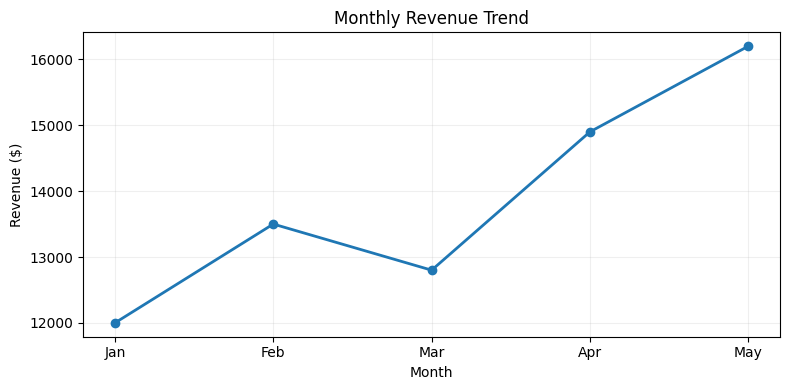

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "month": ["Jan", "Feb", "Mar", "Apr", "May"],
    "revenue": [12000, 13500, 12800, 14900, 16200]
})

plt.figure(figsize=(8, 4))
plt.plot(df["month"], df["revenue"], marker="o", linewidth=2)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

C:\Users\62707\AppData\Local\Temp\ipykernel_41552\4143464707.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="channel", y="conversion_rate", palette="Blues_d")


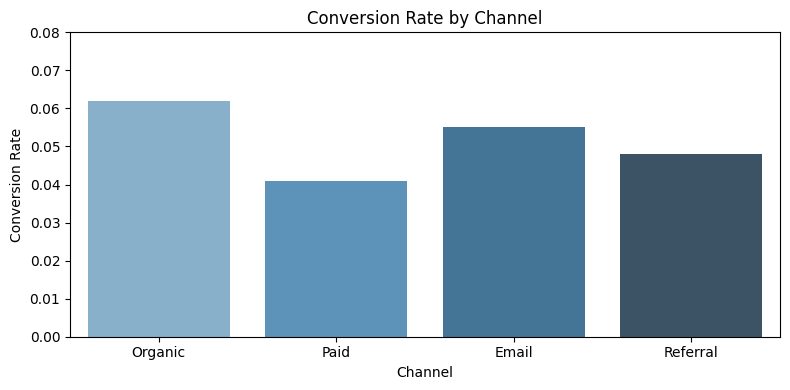

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "channel": ["Organic", "Paid", "Email", "Referral"],
    "conversion_rate": [0.062, 0.041, 0.055, 0.048]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="channel", y="conversion_rate", palette="Blues_d")
plt.title("Conversion Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Conversion Rate")
plt.ylim(0, 0.08)
plt.tight_layout()
plt.show()

In [9]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
import pandas as pd

output_notebook()  # Enables inline display of Bokeh plots in classic Jupyter notebooks

df = pd.DataFrame({
    "day": pd.date_range("2025-05-01", periods=7, freq="D"),
    "dau": [820, 860, 845, 900, 940, 915, 970]
})

source = ColumnDataSource(df)
p = figure(
    x_axis_type="datetime",
    title="Daily Active Users (Interactive)",
    width=800,
    height=350,
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

p.line("day", "dau", source=source, line_width=2)
p.circle("day", "dau", source=source, size=6)
p.add_tools(HoverTool(
    tooltips=[("Date", "@day{%F}"), ("DAU", "@dau")],
    formatters={"@day": "datetime"}
))

show(p)

Loading BokehJS ...